In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

pd.set_option("display.width", 2000)        # use very wide width
pd.set_option("display.max_columns", None)  # show all columns
pd.set_option("display.max_colwidth", None) # do not truncate text
pd.set_option("display.expand_frame_repr", False)  # no wrapping

In [19]:

df = pd.read_parquet("data/processed/cfr_savings_processed.parquet")
print(f"Rows: {len(df)} | Columns: {len(df.columns)}")
print(df.columns.tolist())

Rows: 13194 | Columns: 119
['case_number', 'case_priority', 'case_type', 'subject', 'creation_date', 'disposition_date', 'teco_date', 'market', 'country', 'ib_service_team', 'remote_remarks', 'field_remarks', 'remote_remarks_en', 'field_remarks_en', 'equipment', 'system_code', 'parts_consumed_list', 'remote_hours', 'travel_hours', 'onsite_hours', 'offsite_hours', 'total_hours', 'ttsu_days', 'ttsu_bucket', 'diagnostic_text', 'diagnostic_date', 'follow_up_text', 'follow_up_date', 'problem_description_text', 'problem_description_date', 'resolution_text', 'resolution_date', 'internal_comments_text', 'internal_comments_date', 'internal_remarks_text', 'internal_remarks_date', 'external_remarks_text', 'external_remarks_date', 'parent_diagnostic_text', 'parent_diagnostic_date', 'parent_follow_up_text', 'parent_follow_up_date', 'parent_problem_description_text', 'parent_problem_description_date', 'parent_resolution_text', 'parent_resolution_date', 'parent_internal_comments_text', 'parent_intern

In [20]:
print(df["diagnostic_text"].notna().sum())

3002


In [21]:
country_count = (
    df.groupby('country')
      .size()
      .reset_index(name='count')
      .sort_values('count', ascending=False)
)

C:\Users\320305732\AppData\Local\Temp\ipykernel_25444\3382592043.py:27: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", min(TOP_N, 20))


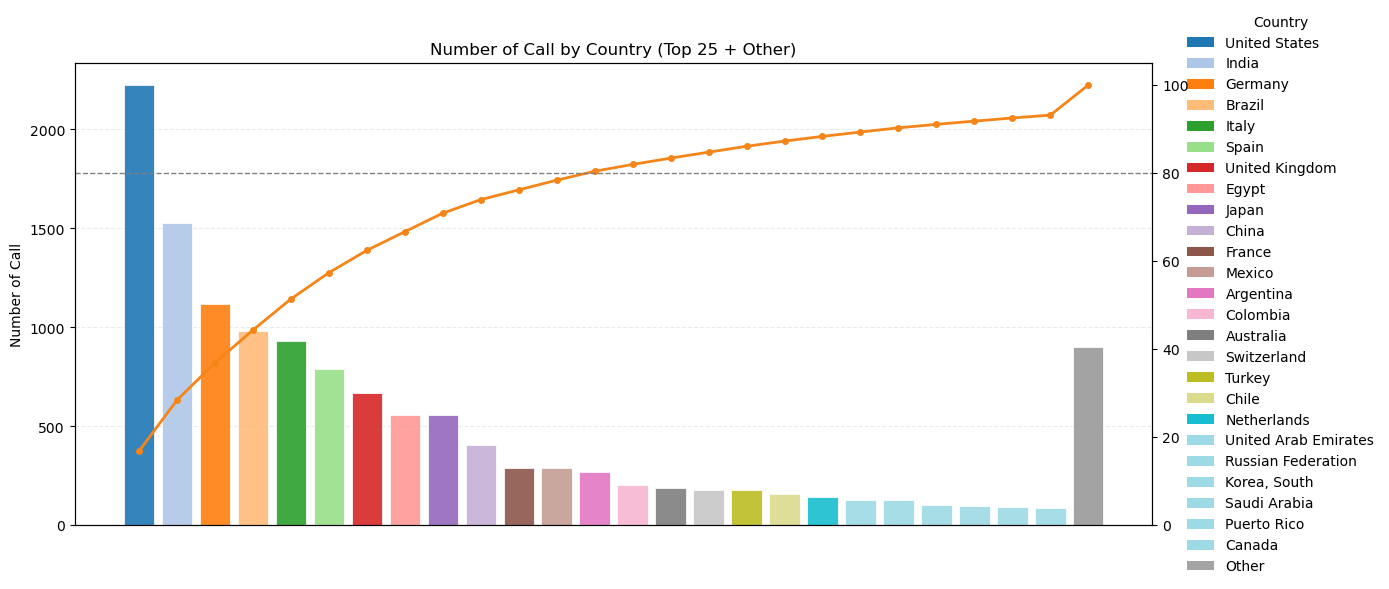

In [22]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch

TOP_N = 25

# --- Build Top N + Other ---
cc = country_count.copy()
cc["country"] = cc["country"].astype(str)
cc["count"] = cc["count"].astype(float)

top = cc.head(TOP_N).copy()
other = cc["count"].iloc[TOP_N:].sum()

if other > 0:
    plot_df = pd.concat(
        [top, pd.DataFrame([{"country": "Other", "count": other}])],
        ignore_index=True
    )
else:
    plot_df = top.copy()

plot_df["cum_pct"] = plot_df["count"].cumsum() / plot_df["count"].sum() * 100

# --- Colors (Top 20 + gray for Other) ---
cmap = plt.cm.get_cmap("tab20", min(TOP_N, 20))
colors = [cmap(i) for i in range(len(plot_df))]
if plot_df["country"].iloc[-1] == "Other":
    colors[-1] = (0.6, 0.6, 0.6, 0.9)

# --- Plot ---
x = np.arange(len(plot_df))

fig, ax = plt.subplots(figsize=(14, 6))

ax.bar(x, plot_df["count"], color=colors, alpha=0.9, edgecolor="white", linewidth=0.6)
ax.set_ylabel("Number of Call")
ax.set_title(f"Number of Call by Country (Top {TOP_N} + Other)")
ax.yaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Remove x-axis tick labels (legend will be used instead)
ax.set_xticks([])
ax.set_xlabel("")  # no label under bars

# Pareto line (secondary axis)
ax2 = ax.twinx()
ax2.plot(x, plot_df["cum_pct"], color="#F58518", marker="o", linewidth=2, markersize=4)
#ax2.set_ylabel("Cumulative %")
ax2.set_ylim(0, 105)
ax2.axhline(80, color="gray", linestyle="--", linewidth=1)

# Legend on the right (one entry per bar)
handles = [Patch(facecolor=colors[i], edgecolor="none") for i in range(len(plot_df))]
labels = plot_df["country"].tolist()

ax.legend(
    handles, labels,
    title="Country",
    loc="center left",
    bbox_to_anchor=(1.02, 0.5),
    frameon=False
)

plt.tight_layout()
plt.show()

# Missing values

## Call Missing Values

In [23]:
n = len(df)

field_missing = df["field_remarks"].isna().sum()
remote_missing = df["remote_remarks"].isna().sum()

field_missing_pct = round(field_missing / n * 100, 1)
remote_missing_pct = round(remote_missing / n * 100, 1)

print(f"Total rows: {n}")
print(f"field_remarks missing (NaN):  {field_missing} ({field_missing_pct}%)")
print(f"remote_remarks missing (NaN): {remote_missing} ({remote_missing_pct}%)")

Total rows: 13194
field_remarks missing (NaN):  5596 (42.4%)
remote_remarks missing (NaN): 905 (6.9%)


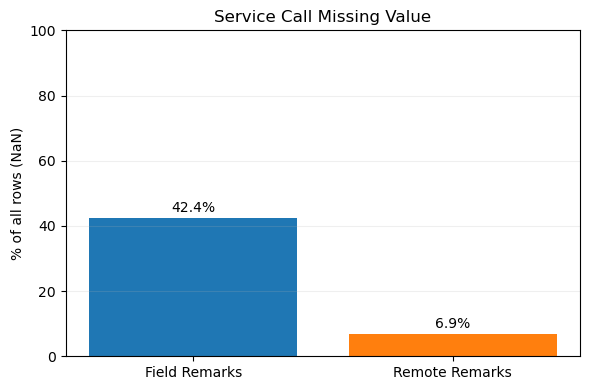

In [24]:
import matplotlib.pyplot as plt

labels = ["Field Remarks", "Remote Remarks"]
pcts = [field_missing_pct, remote_missing_pct]
colors = ["tab:blue", "tab:orange"]

fig, ax = plt.subplots(figsize=(6, 4))
ax.bar(labels, pcts, color=colors)

ax.set_title("Service Call Missing Value")
ax.set_ylabel("% of all rows (NaN)")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)

for i, v in enumerate(pcts):
    ax.text(i, v + 1, f"{v}%", ha="center", va="bottom")

plt.tight_layout()
plt.show()

Missing values by country

In [25]:
import pandas as pd
import numpy as np

missing_by_country = df.groupby("country").agg(
    n_rows=("country", "size"),
    field_missing=("field_remarks", lambda s: s.isna().sum()),
    remote_missing=("remote_remarks", lambda s: s.isna().sum()),
).reset_index()

missing_by_country["field_missing_pct"] = (missing_by_country["field_missing"] / missing_by_country["n_rows"] * 100).round(1)
missing_by_country["remote_missing_pct"] = (missing_by_country["remote_missing"] / missing_by_country["n_rows"] * 100).round(1)

# (optional) sort by volume descending
missing_by_country = missing_by_country.sort_values("n_rows", ascending=False).reset_index(drop=True)

missing_by_country

,country,n_rows,field_missing,remote_missing,field_missing_pct,remote_missing_pct
0,United States,2224,833,254,37.5,11.4
1,India,1526,415,0,27.2,0.0
2,Germany,1119,455,64,40.7,5.7
3,Brazil,981,914,102,93.2,10.4
4,Italy,931,387,23,41.6,2.5
5,Spain,788,391,47,49.6,6.0
6,United Kingdom,670,291,60,43.4,9.0
7,Egypt,559,362,9,64.8,1.6
8,Japan,555,4,0,0.7,0.0
9,China,406,38,18,9.4,4.4


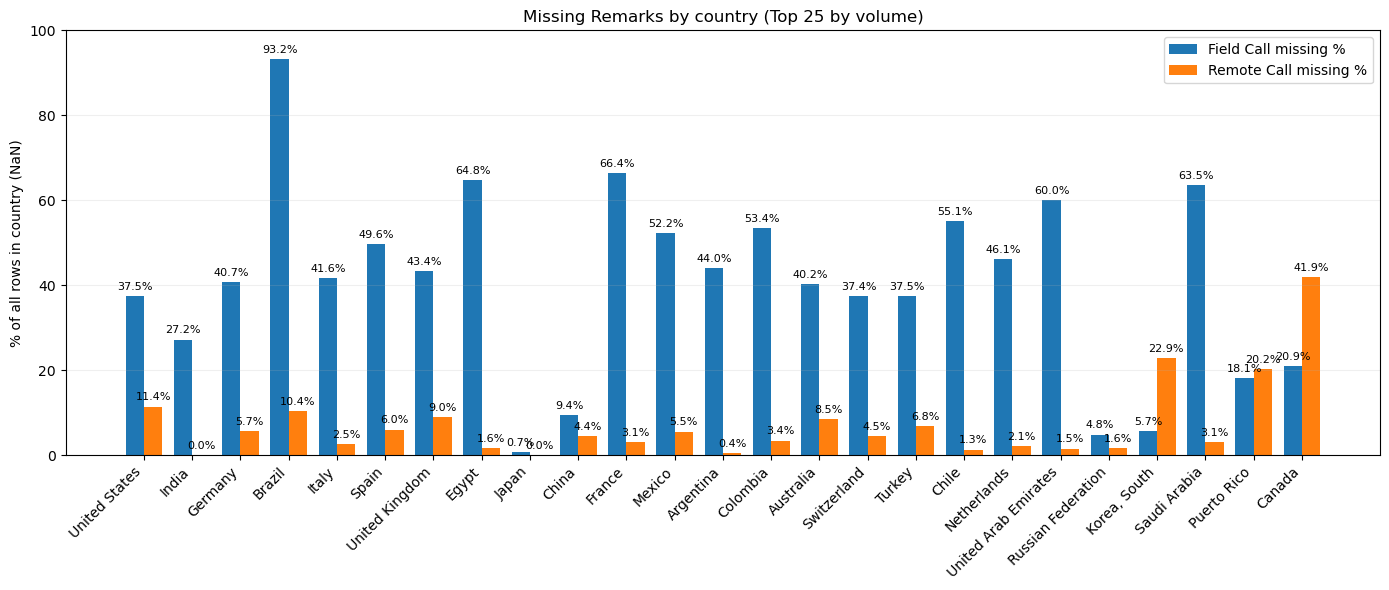

In [26]:
import numpy as np
import matplotlib.pyplot as plt

# assumes you already created `missing_by_country` from the previous snippet
top_n = 25
top25 = missing_by_country.sort_values("n_rows", ascending=False).head(top_n).copy()

x = np.arange(len(top25))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))

# blue = field, orange = remote
ax.bar(x - w/2, top25["field_missing_pct"], width=w, color="tab:blue", label="Field Call missing %")
ax.bar(x + w/2, top25["remote_missing_pct"], width=w, color="tab:orange", label="Remote Call missing %")

ax.set_title("Missing Remarks by country (Top 25 by volume)")
ax.set_ylabel("% of all rows in country (NaN)")
ax.set_xticks(x)
ax.set_xticklabels(top25["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

# optional: annotate bars
for i, (fv, rv) in enumerate(zip(top25["field_missing_pct"], top25["remote_missing_pct"])):
    ax.text(i - w/2, fv + 1, f"{fv:.1f}%", ha="center", va="bottom", fontsize=8)
    ax.text(i + w/2, rv + 1, f"{rv:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Part Consumed 

In [27]:
n = len(df)

parts_non_missing = df["parts_consumed_list"].notna().sum()
parts_non_missing_pct = round(parts_non_missing / n * 100, 1)

print(f"Total rows: {n}")
print(f"parts_consumed_list not-NaN: {parts_non_missing} ({parts_non_missing_pct}%)")

Total rows: 13194
parts_consumed_list not-NaN: 4567 (34.6%)


C:\Users\320305732\AppData\Local\Temp\ipykernel_25444\1524698444.py:17: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm.get_cmap("viridis")(0.7),  # green-ish
C:\Users\320305732\AppData\Local\Temp\ipykernel_25444\1524698444.py:18: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cm.get_cmap("viridis")(0.3),  # blue/purple


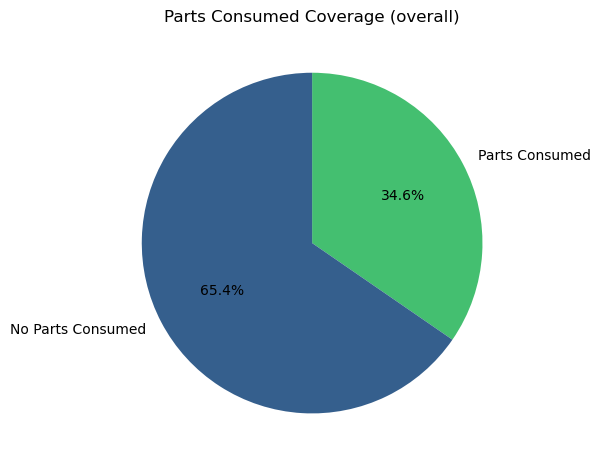

In [28]:
import matplotlib.pyplot as plt
import matplotlib.cm as cm

# percentages
sizes = [
    parts_non_missing_pct,
    100 - parts_non_missing_pct
]

labels = [
    "Parts Consumed",
    "No Parts Consumed"
]

# viridis palette
colors = [
    cm.get_cmap("viridis")(0.7),  # green-ish
    cm.get_cmap("viridis")(0.3),  # blue/purple
]

fig, ax = plt.subplots(figsize=(6, 6))

ax.pie(
    sizes,
    labels=labels,
    colors=colors,
    autopct="%1.1f%%",
    startangle=90,
    counterclock=False
)

ax.set_title("Parts Consumed Coverage (overall)")

plt.tight_layout()
plt.show()

In [29]:
import pandas as pd

parts_by_country = df.groupby("country").agg(
    n_rows=("country", "size"),
    parts_non_missing=("parts_consumed_list", lambda s: s.notna().sum()),
).reset_index()

parts_by_country["parts_non_missing_pct"] = (
    parts_by_country["parts_non_missing"] / parts_by_country["n_rows"] * 100
).round(1)

# optional: sort by volume (descending)
parts_by_country = parts_by_country.sort_values("n_rows", ascending=False).reset_index(drop=True)

#parts_by_country

C:\Users\320305732\AppData\Local\Temp\ipykernel_25444\819829395.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  green = cm.get_cmap("viridis")(0.7)


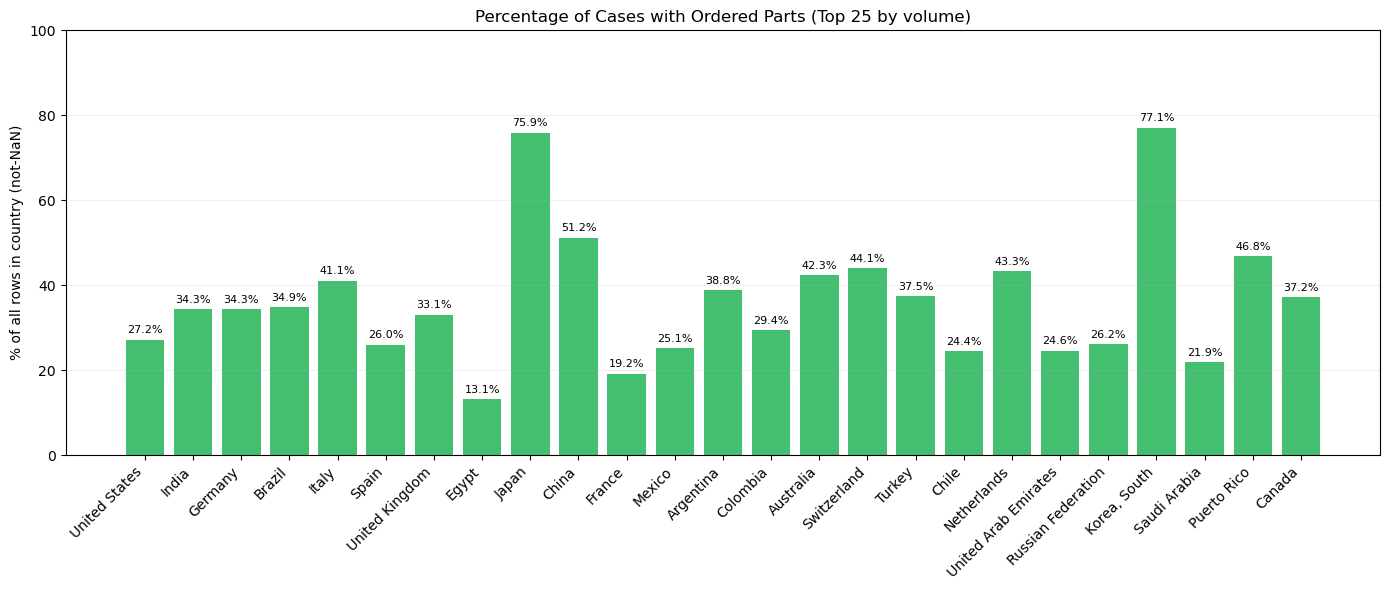

In [30]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm

green = cm.get_cmap("viridis")(0.7)

top_n = 25
top25 = parts_by_country.sort_values("n_rows", ascending=False).head(top_n).copy()

x = np.arange(len(top25))

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x, top25["parts_non_missing_pct"], color=green)

ax.set_title("Percentage of Cases with Ordered Parts (Top 25 by volume)")
ax.set_ylabel("% of all rows in country (not-NaN)")
ax.set_xticks(x)
ax.set_xticklabels(top25["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.grid(axis="y", alpha=0.2)

# optional annotations
for i, v in enumerate(top25["parts_non_missing_pct"]):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

## Extraction percentage

In [32]:
df_nam = df[df["market"] == "NAM"]

In [39]:
print(df_nam.head(15))

     case_number  case_priority case_type                                                                          subject creation_date disposition_date  teco_date market        country ib_service_team                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

In [36]:
key_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote", 
    "extracted_diagnostic_field"
]

for col in key_cols:
    filled = df_nam[col].notna().sum()
    pct = round(filled / len(df_nam) * 100, 1)
    print(f"{col}: {filled} ({pct}%)")

extracted_problem_description_field: 1143 (49.5%)
extracted_error_field: 0 (0.0%)
extracted_malfunction_area_field: 305 (13.2%)
extracted_troubleshooting_field: 0 (0.0%)
extracted_repair_action_field: 1338 (57.9%)
extracted_problem_description_remote: 1803 (78.1%)
extracted_error_remote: 507 (21.9%)
extracted_malfunction_area_remote: 533 (23.1%)
extracted_troubleshooting_remote: 0 (0.0%)
extracted_repair_action_remote: 1785 (77.3%)
extracted_diagnostic_remote: 1742 (75.4%)
extracted_diagnostic_field: 640 (27.7%)


In [37]:
key_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
    "extracted_diagnostic_remote", 
    "extracted_diagnostic_field"
]

for col in key_cols:
    filled = df[col].notna().sum()
    pct = round(filled / len(df) * 100, 1)
    print(f"{col}: {filled} ({pct}%)")

extracted_problem_description_field: 5861 (44.4%)
extracted_error_field: 12 (0.1%)
extracted_malfunction_area_field: 2961 (22.4%)
extracted_troubleshooting_field: 27 (0.2%)
extracted_repair_action_field: 6593 (50.0%)
extracted_problem_description_remote: 11402 (86.4%)
extracted_error_remote: 3993 (30.3%)
extracted_malfunction_area_remote: 5732 (43.4%)
extracted_troubleshooting_remote: 1365 (10.3%)
extracted_repair_action_remote: 10108 (76.6%)
extracted_diagnostic_remote: 9901 (75.0%)
extracted_diagnostic_field: 2679 (20.3%)


extracted problem description

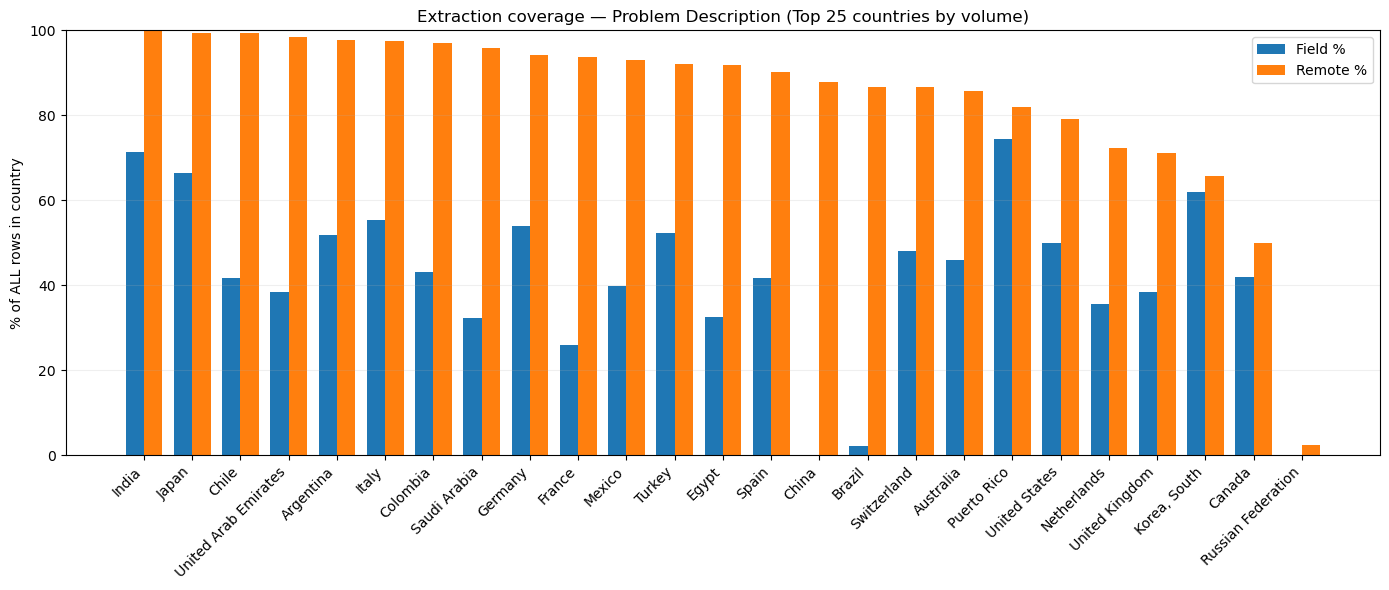

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
top_n = 25
country_col = "country"
field_col = "extracted_problem_description_field"
remote_col = "extracted_problem_description_remote"

# --- top countries by volume ---
top_countries = df[country_col].value_counts().head(top_n).index
dft = df[df[country_col].isin(top_countries)].copy()

# keep order = descending volume
order = dft[country_col].value_counts().loc[top_countries].index.tolist()

# --- compute % over ALL rows per country ---
grp = dft.groupby(country_col)
summary = pd.DataFrame({
    "country": order,
    "n_rows": grp.size().reindex(order).values,
    "field_pct": (grp[field_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
    "remote_pct": (grp[remote_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
})

summary = summary.sort_values("remote_pct", ascending=False).reset_index(drop=True)

# --- plot ---
x = np.arange(len(summary))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, summary["field_pct"], width=w, label="Field %")
ax.bar(x + w/2, summary["remote_pct"], width=w, label="Remote %")

ax.set_title("Extraction coverage of Problem Description Section (Top 25 countries by volume)")
ax.set_ylabel("% of ALL rows in country")
ax.set_xticks(x)
ax.set_xticklabels(summary["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

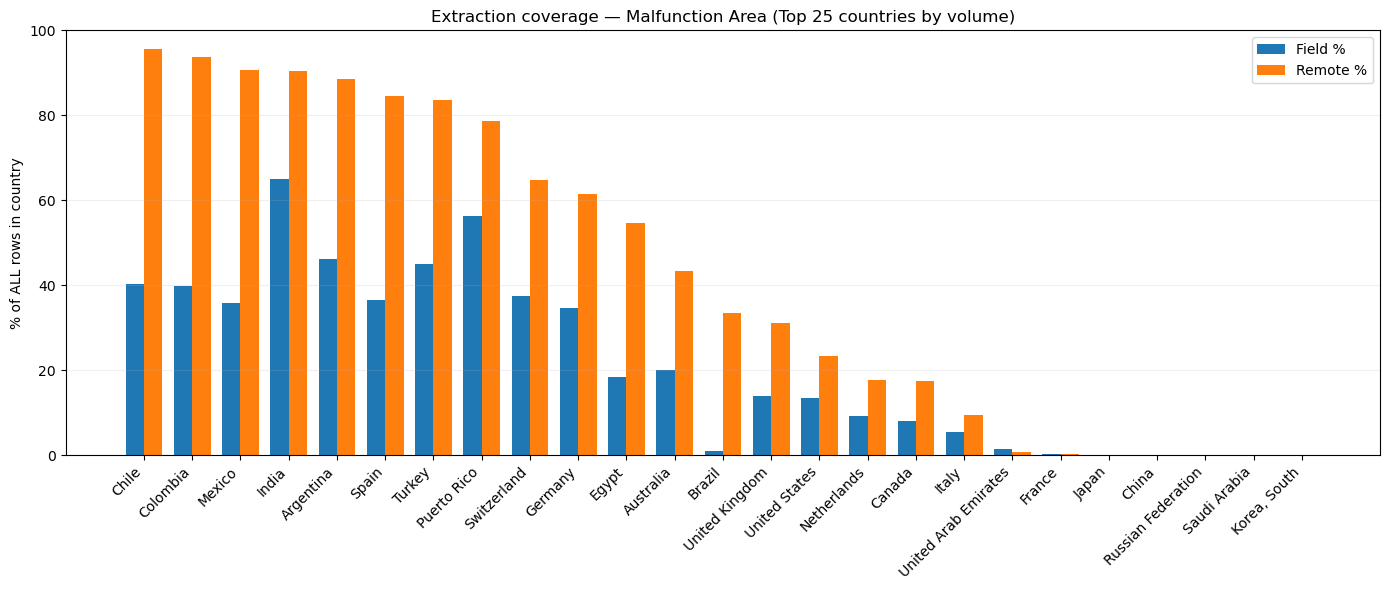

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
top_n = 25
country_col = "country"
field_col = "extracted_malfunction_area_field"
remote_col = "extracted_malfunction_area_remote"

# --- top countries by volume ---
top_countries = df[country_col].value_counts().head(top_n).index
dft = df[df[country_col].isin(top_countries)].copy()

# keep order = descending volume
order = dft[country_col].value_counts().loc[top_countries].index.tolist()

# --- compute % over ALL rows per country ---
grp = dft.groupby(country_col)
summary = pd.DataFrame({
    "country": order,
    "n_rows": grp.size().reindex(order).values,
    "field_pct": (grp[field_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
    "remote_pct": (grp[remote_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
})

summary = summary.sort_values("remote_pct", ascending=False).reset_index(drop=True)

# --- plot ---
x = np.arange(len(summary))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, summary["field_pct"], width=w, label="Field %")
ax.bar(x + w/2, summary["remote_pct"], width=w, label="Remote %")

ax.set_title("Extraction coverage of Malfunction Area Sub-Section (Top 25 countries by volume)")
ax.set_ylabel("% of total rows in the country")
ax.set_xticks(x)
ax.set_xticklabels(summary["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

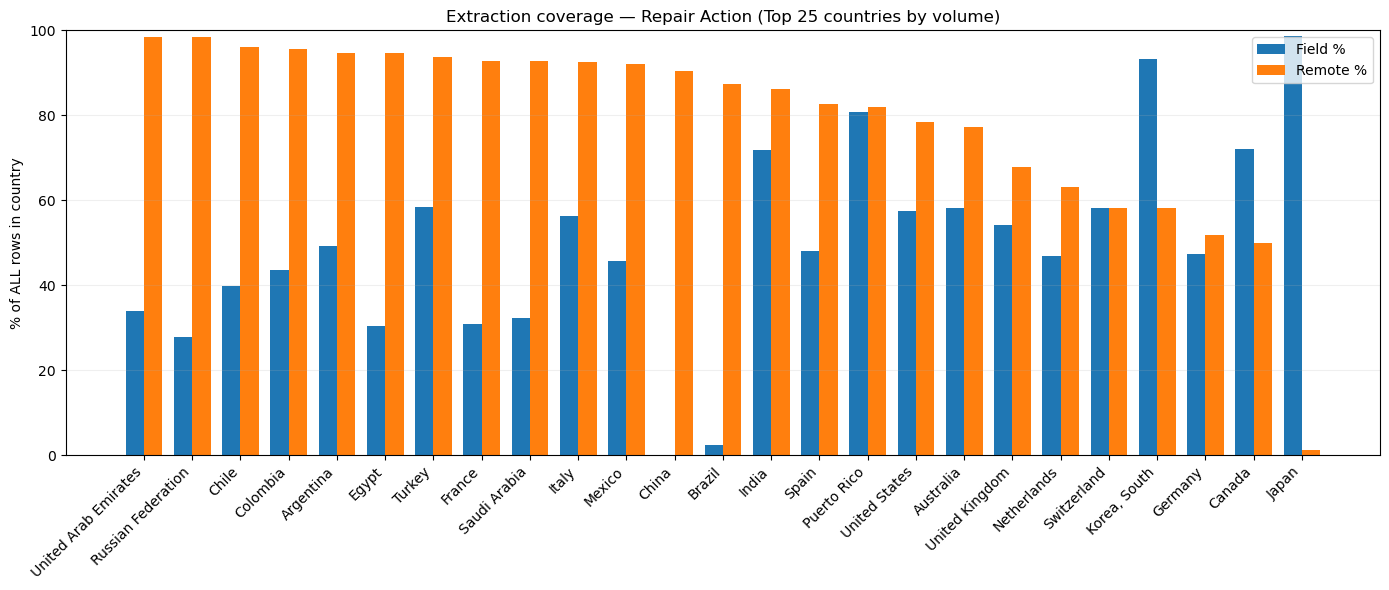

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --- settings ---
top_n = 25
country_col = "country"
field_col = "extracted_repair_action_field"
remote_col = "extracted_repair_action_remote"

# --- top countries by volume ---
top_countries = df[country_col].value_counts().head(top_n).index
dft = df[df[country_col].isin(top_countries)].copy()

# keep order = descending volume
order = dft[country_col].value_counts().loc[top_countries].index.tolist()

# --- compute % over ALL rows per country ---
grp = dft.groupby(country_col)
summary = pd.DataFrame({
    "country": order,
    "n_rows": grp.size().reindex(order).values,
    "field_pct": (grp[field_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
    "remote_pct": (grp[remote_col].apply(lambda s: s.notna().mean()) * 100).reindex(order).values,
})
summary = summary.sort_values("remote_pct", ascending=False).reset_index(drop=True)

# --- plot ---
x = np.arange(len(summary))
w = 0.38

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar(x - w/2, summary["field_pct"], width=w, label="Field %")
ax.bar(x + w/2, summary["remote_pct"], width=w, label="Remote %")

ax.set_title("Extraction coverage of Repair Action Sub-Section (Top 25 countries by volume)")
ax.set_ylabel("% of total rows in the country")
ax.set_xticks(x)
ax.set_xticklabels(summary["country"], rotation=45, ha="right")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.2)

plt.tight_layout()
plt.show()

#### by country

In [13]:
import pandas as pd
import numpy as np

field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

rows = []

# Denominator per country = ALL rows in that country
country_den = df.groupby("country").size()  # total rows per country

# ---- FIELD block ----
for col in field_cols:
    extracted = df.groupby("country")[col].apply(lambda s: s.notna().sum())

    tmp = pd.DataFrame({
        "country": country_den.index,
        "scope": "field",
        "variable": col,
        "extracted_count": extracted.reindex(country_den.index).fillna(0).astype(int).values,
        "eligible_count": country_den.values.astype(int),  # <- now total rows in country
    })

    tmp["extraction_pct"] = np.where(
        tmp["eligible_count"] > 0,
        (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
        0.0
    )
    rows.append(tmp)

# ---- REMOTE block ----
for col in remote_cols:
    extracted = df.groupby("country")[col].apply(lambda s: s.notna().sum())

    tmp = pd.DataFrame({
        "country": country_den.index,
        "scope": "remote",
        "variable": col,
        "extracted_count": extracted.reindex(country_den.index).fillna(0).astype(int).values,
        "eligible_count": country_den.values.astype(int),
    })

    tmp["extraction_pct"] = np.where(
        tmp["eligible_count"] > 0,
        (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
        0.0
    )
    rows.append(tmp)

country_extraction_summary_allrows = (
    pd.concat(rows, ignore_index=True)
      .sort_values(["scope", "variable", "extraction_pct"], ascending=[True, True, False])
      .reset_index(drop=True)
)

country_extraction_summary_allrows

,country,scope,variable,extracted_count,eligible_count,extraction_pct
0,Austria,field,extracted_error_field,3,48,6.2
1,Thailand,field,extracted_error_field,1,51,2.0
2,Egypt,field,extracted_error_field,5,559,0.9
3,Mexico,field,extracted_error_field,1,291,0.3
4,United Kingdom,field,extracted_error_field,2,670,0.3
...,...,...,...,...,...,...
525,Thailand,remote,extracted_troubleshooting_remote,0,51,0.0
526,United Arab Emirates,remote,extracted_troubleshooting_remote,0,130,0.0
527,United Kingdom,remote,extracted_troubleshooting_remote,0,670,0.0
528,United States,remote,extracted_troubleshooting_remote,1,2224,0.0


In [14]:
key_cols = field_cols + remote_cols

country_key_summary = (
    df.groupby("country")[key_cols]
      .apply(lambda g: g.notna().sum())
      .astype(int)
      .join(df.groupby("country").size().rename("total_rows"))
)

country_key_pct = (
    country_key_summary[key_cols]
    .div(country_key_summary["total_rows"], axis=0)
    .mul(100)
    .round(1)
)

# long format (handy for plots)
country_key_long = (
    country_key_summary[key_cols]
    .stack()
    .rename("filled")
    .reset_index()
    .rename(columns={"level_1": "variable"})
    .merge(country_key_summary["total_rows"].reset_index(), on="country", how="left")
)

country_key_long["pct"] = (country_key_long["filled"] / country_key_long["total_rows"] * 100).round(1)
country_key_long.sort_values(["variable", "pct"], ascending=[True, False]).reset_index(drop=True)

,country,variable,filled,total_rows,pct
0,Austria,extracted_error_field,3,48,6.2
1,Thailand,extracted_error_field,1,51,2.0
2,Egypt,extracted_error_field,5,559,0.9
3,Mexico,extracted_error_field,1,291,0.3
4,United Kingdom,extracted_error_field,2,670,0.3
...,...,...,...,...,...
525,Thailand,extracted_troubleshooting_remote,0,51,0.0
526,United Arab Emirates,extracted_troubleshooting_remote,0,130,0.0
527,United Kingdom,extracted_troubleshooting_remote,0,670,0.0
528,United States,extracted_troubleshooting_remote,1,2224,0.0


### On non nana value

In [8]:
field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

# Denominators
field_den = df["field_remarks"].notna().sum()
remote_den = df["remote_remarks"].notna().sum()

# Field-based extraction %
for col in field_cols:
    extracted = df.loc[df["field_remarks"].notna(), col].notna().sum()
    pct = round(extracted / field_den * 100, 1) if field_den else 0.0
    print(f"{col}: {extracted} / {field_den} ({pct}%)")

# Remote-based extraction %
for col in remote_cols:
    extracted = df.loc[df["remote_remarks"].notna(), col].notna().sum()
    pct = round(extracted / remote_den * 100, 1) if remote_den else 0.0
    print(f"{col}: {extracted} / {remote_den} ({pct}%)")

extracted_problem_description_field: 5844 / 7598 (76.9%)
extracted_error_field: 12 / 7598 (0.2%)
extracted_malfunction_area_field: 2954 / 7598 (38.9%)
extracted_troubleshooting_field: 27 / 7598 (0.4%)
extracted_repair_action_field: 6572 / 7598 (86.5%)
extracted_problem_description_remote: 11385 / 12289 (92.6%)
extracted_error_remote: 3994 / 12289 (32.5%)
extracted_malfunction_area_remote: 5722 / 12289 (46.6%)
extracted_troubleshooting_remote: 1366 / 12289 (11.1%)
extracted_repair_action_remote: 10087 / 12289 (82.1%)


In [9]:
field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

rows = []

# Denominators
field_den = df["field_remarks"].notna().sum()
remote_den = df["remote_remarks"].notna().sum()

# Field-based metrics
for col in field_cols:
    extracted = df.loc[df["field_remarks"].notna(), col].notna().sum()
    pct = round(extracted / field_den * 100, 1) if field_den else 0.0

    rows.append({
        "scope": "field",
        "variable": col,
        "extracted_count": extracted,
        "eligible_count": field_den,
        "extraction_pct": pct,
    })

# Remote-based metrics
for col in remote_cols:
    extracted = df.loc[df["remote_remarks"].notna(), col].notna().sum()
    pct = round(extracted / remote_den * 100, 1) if remote_den else 0.0

    rows.append({
        "scope": "remote",
        "variable": col,
        "extracted_count": extracted,
        "eligible_count": remote_den,
        "extraction_pct": pct,
    })

extraction_summary = pd.DataFrame(rows)
extraction_summary

,scope,variable,extracted_count,eligible_count,extraction_pct
0,field,extracted_problem_description_field,5844,7598,76.9
1,field,extracted_error_field,12,7598,0.2
2,field,extracted_malfunction_area_field,2954,7598,38.9
3,field,extracted_troubleshooting_field,27,7598,0.4
4,field,extracted_repair_action_field,6572,7598,86.5
5,remote,extracted_problem_description_remote,11385,12289,92.6
6,remote,extracted_error_remote,3994,12289,32.5
7,remote,extracted_malfunction_area_remote,5722,12289,46.6
8,remote,extracted_troubleshooting_remote,1366,12289,11.1
9,remote,extracted_repair_action_remote,10087,12289,82.1


In [10]:
import pandas as pd
import numpy as np

field_cols = [
    "extracted_problem_description_field",
    "extracted_error_field",
    "extracted_malfunction_area_field",
    "extracted_troubleshooting_field",
    "extracted_repair_action_field",
]

remote_cols = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

def build_country_extraction_summary(df, country_col="country"):
    rows = []

    # ---- FIELD ----
    eligible_field = df[df["field_remarks"].notna()]
    field_den_by_country = eligible_field.groupby(country_col).size()  # eligible_count

    for col in field_cols:
        extracted_by_country = (
            eligible_field.groupby(country_col)[col]
            .apply(lambda s: s.notna().sum())
        )

        tmp = pd.DataFrame({
            "country": field_den_by_country.index,
            "scope": "field",
            "variable": col,
            "extracted_count": extracted_by_country.reindex(field_den_by_country.index).fillna(0).astype(int).values,
            "eligible_count": field_den_by_country.values.astype(int),
        })
        tmp["extraction_pct"] = np.where(
            tmp["eligible_count"] > 0,
            (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
            0.0
        )
        rows.append(tmp)

    # ---- REMOTE ----
    eligible_remote = df[df["remote_remarks"].notna()]
    remote_den_by_country = eligible_remote.groupby(country_col).size()

    for col in remote_cols:
        extracted_by_country = (
            eligible_remote.groupby(country_col)[col]
            .apply(lambda s: s.notna().sum())
        )

        tmp = pd.DataFrame({
            "country": remote_den_by_country.index,
            "scope": "remote",
            "variable": col,
            "extracted_count": extracted_by_country.reindex(remote_den_by_country.index).fillna(0).astype(int).values,
            "eligible_count": remote_den_by_country.values.astype(int),
        })
        tmp["extraction_pct"] = np.where(
            tmp["eligible_count"] > 0,
            (tmp["extracted_count"] / tmp["eligible_count"] * 100).round(1),
            0.0
        )
        rows.append(tmp)

    out = pd.concat(rows, ignore_index=True)

    # optional: nicer variable labels (remove prefix)
    out["variable"] = out["variable"].str.replace("extracted_", "", regex=False)

    return out.sort_values(["scope", "variable", "extraction_pct"], ascending=[True, True, False]).reset_index(drop=True)

country_extraction_summary = build_country_extraction_summary(df)
country_extraction_summary

,country,scope,variable,extracted_count,eligible_count,extraction_pct
0,Austria,field,error_field,3,33,9.1
1,Egypt,field,error_field,5,197,2.5
2,Thailand,field,error_field,1,44,2.3
3,Mexico,field,error_field,1,139,0.7
4,United Kingdom,field,error_field,2,379,0.5
...,...,...,...,...,...,...
515,Switzerland,remote,troubleshooting_remote,0,171,0.0
516,Thailand,remote,troubleshooting_remote,0,29,0.0
517,United Arab Emirates,remote,troubleshooting_remote,0,128,0.0
518,United Kingdom,remote,troubleshooting_remote,0,610,0.0


In [11]:
pivot_field = (
    country_extraction_summary[country_extraction_summary["scope"] == "field"]
    .pivot(index="country", columns="variable", values="extraction_pct")
    .sort_index()
)

pivot_remote = (
    country_extraction_summary[country_extraction_summary["scope"] == "remote"]
    .pivot(index="country", columns="variable", values="extraction_pct")
    .sort_index()
)

pivot_field, pivot_remote


(variable              error_field  malfunction_area_field  problem_description_field  repair_action_field  troubleshooting_field
 country                                                                                                                         
 Argentina                     0.0                    82.7                       92.7                 88.0                    0.0
 Australia                     0.0                    33.6                       77.0                 97.3                    0.0
 Austria                       9.1                    36.4                       81.8                 84.8                    0.0
 Bangladesh                    0.0                     0.0                       70.0                100.0                    0.0
 Belgium                       0.0                    10.3                       64.1                 94.9                    0.0
 Brazil                        0.0                     3.0                        7.5     

In [12]:
top_n = 20
top_countries_field = (
    country_extraction_summary[country_extraction_summary["scope"]=="field"]
    .groupby("country")["eligible_count"].max()
    .sort_values(ascending=False)
    .head(top_n)
    .index
)

country_extraction_summary_top = country_extraction_summary[
    country_extraction_summary["country"].isin(top_countries_field)
]

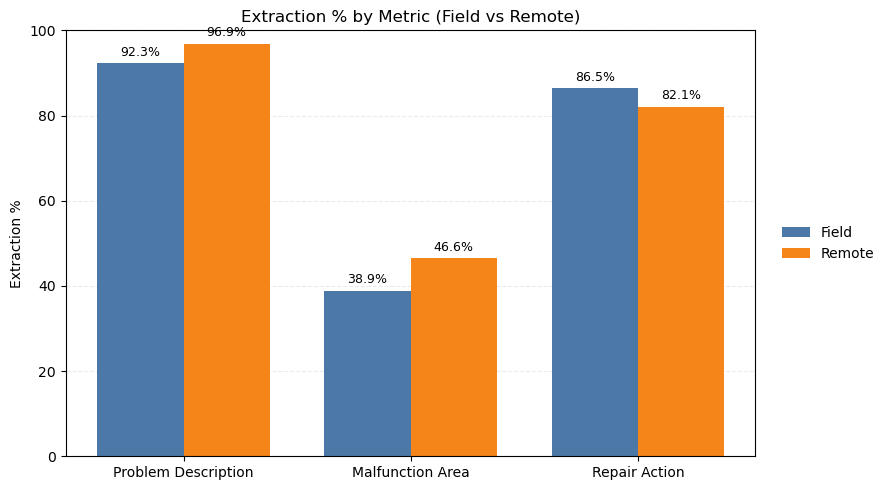

In [65]:
import numpy as np
import matplotlib.pyplot as plt

# Metrics you want to compare
metrics = [
    "problem_description",
    "malfunction_area",
    "repair_action",
]

field_cols  = [f"extracted_{m}_field"  for m in metrics]
remote_cols = [f"extracted_{m}_remote" for m in metrics]

# Denominators (eligible rows)
field_mask  = df["field_remarks"].notna()
remote_mask = df["remote_remarks"].notna()
field_den   = field_mask.sum()
remote_den  = remote_mask.sum()

# Percentages
field_pct = [(df.loc[field_mask,  c].notna().sum() / field_den  * 100) if field_den  else 0 for c in field_cols]
remote_pct = [(df.loc[remote_mask, c].notna().sum() / remote_den * 100) if remote_den else 0 for c in remote_cols]

# Plot (grouped bars)
x = np.arange(len(metrics))
w = 0.38

fig, ax = plt.subplots(figsize=(9, 5))

ax.bar(x - w/2, field_pct,  width=w, color="#4C78A8", label="Field")
ax.bar(x + w/2, remote_pct, width=w, color="#F58518", label="Remote")

ax.set_xticks(x)
ax.set_xticklabels([m.replace("_", " ").title() for m in metrics])
ax.set_ylabel("Extraction %")
ax.set_ylim(0, 100)
ax.set_title("Extraction % by Metric (Field vs Remote)")
ax.yaxis.grid(True, linestyle="--", alpha=0.25)
ax.set_axisbelow(True)

# Value labels on top of bars
for i, v in enumerate(field_pct):
    ax.text(x[i] - w/2, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)
for i, v in enumerate(remote_pct):
    ax.text(x[i] + w/2, v + 1, f"{v:.1f}%", ha="center", va="bottom", fontsize=9)

ax.legend(loc="center left", bbox_to_anchor=(1.02, 0.5), frameon=False)

plt.tight_layout()
plt.show()

In [36]:
sample = df[df["extracted_problem_description_field"].notna()].iloc[0]
print("Problem:", sample["extracted_problem_description_field"])
print("Repair:", sample["extracted_repair_action_field"])
print("Malfunction:", sample["extracted_malfunction_area_field"])

Problem: Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the breakers,  No PRS connection, Remote password is not set,
Repair: nan
Malfunction: nan


In [37]:
mask = df["extracted_problem_description_field"].isna()
print(df[mask]["diagnostic_text"].notna().sum())

204


In [38]:
mask = (
    df["extracted_problem_description_field"].isna() &
    df["diagnostic_text"].notna()
)
print(df[mask].iloc[0]["diagnostic_text"][:300])

In [39]:
mask = (
    df["extracted_problem_description_field"].isna() &
    df["diagnostic_text"].notna()
)

# Check actual values
print(repr(df[mask].iloc[0]["diagnostic_text"]))
print(type(df[mask].iloc[0]["diagnostic_text"]))

''
<class 'str'>


Check failed extraction, orginal nan vs problem description None

In [40]:
mask = df["extracted_problem_description_remote"].isna()
print(f"Missing remote problem description: {mask.sum()}")
print(f"Of those, missing remote_remarks entirely: {df[mask]['remote_remarks'].isna().sum()}")

Missing remote problem description: 1912
Of those, missing remote_remarks entirely: 863


In [41]:
# rows that have remote_remarks but failed extraction
mask_failed = (
    df["extracted_problem_description_remote"].isna() & 
    df["remote_remarks"].notna()
)

# check country distribution of failures
print(df[mask_failed]["country"].value_counts().head(10))

# look at a raw example
print(df[mask_failed].iloc[0]["remote_remarks_en"][:500])

country
United States         211
United Kingdom        133
Russian Federation    121
Egypt                  51
Brazil                 49
Spain                  43
Italy                  39
Netherlands            36
China                  31
Germany                30
Name: count, dtype: int64[pyarrow]
*** T2 Activities [2025-06-16 08:06:50]
Troubleshooting Action: Site audit of the system is required, 

To carry out an FRT specialist or a 4K specialist is required, 

This tool will be needed to audit the system after a quench: 

1) FLUKE-435 Power Quality Analyzer,435/001 2654779 4000435001 
2) Resistance meter IS-20/1, which includes clamps 20/1 - 2136, 20/2 - 0744 
3) TC025 - Earth bonding tester â 452298038072[3] 
or TC378 452298038073 EARTH BONDING TESTER Gossen Secutest SIII+(+IEC Leak


In [42]:
# Sample 5 rows per country from top 10 countries
top_countries = df["country"].value_counts().head(10).index

for country in top_countries:
    sample = df[df["country"] == country]["extracted_problem_description_remote"].dropna().head(5)
    print(f"\n=== {country} ===")
    for text in sample:
        print(f"  → {text[:150]}")


=== United States ===
  → Customer states there is error Scan Abort in message center and the device will not scan,  Customer has power cycled system at host pc and at the brea
  → The chiller is down and is not powering back on- Ongoing issue
  → Biomed had question on vertical actuator on the table that is down,
  → The unit will not run after power surge
  → Both UPS's show battery low and system will not come up,

=== India ===
  → Reconstructor aborted after internal error
  → Workstation system is not switching On
  → Compressor Helium return gas line  leakage
  → 497732	2025-04-30 11:56:20,950	Warning	Examcards                      	12368	        	UGTXT: key CONF: Device not configured, Please contact Philips C
  → Table up and down movement not happening

=== Germany ===
  → mit Te Sven Lischer telefoniert,
Die StÃ¶rung wird bestÃ¤tigt,
  → Das gemeldete Problem wird bestÃ¤tigt
  → Mr. Frackiewicz has already shut down the system three times via the circuit breakers, He was as


=== Brazil ===
  → Problem description by engineer: 
The Sense Body coil connector pin was severely damaged and, insisting on its use damaged the two PICU QCH Kit connec
  → Problem description by engineer: 
Customer got in touch reporting equipment not initializing exams, with messages saying "Spectrometer initializing",
  → Alerta MR,M2M,MagnetSealed_Alert V1,5
  → Intercomunicador apresenta falha permanente,
  → Problem description by engineer: 
The reconstructor initialization fails,

=== Italy ===
  → Magnetic field turned off due to problems with the customer's chiller [SEP] Magnetic field turned off due to problems with the customer's chiller
  → Contacted the doctor on duty who informed me that the workstation does not turn on and there is a flashing orange LED,
  → The remote connection shows system completely shut down for 5 hours on the morning of April 20th, resulting in the magnetic field shutting down,
All c
  → Durante esame si Ã¨ bloccata dopo riavvio Âscan resource n

In [43]:
case = df[df["case_number"] == 125721564].iloc[0]

# Raw input
print("=== RAW REMOTE REMARKS ===")
print(case["remote_remarks_en"])

print("\n=== LAYER 1 — Intermediate columns ===")
print("t2_activities_text_remote:", repr(case["t2_activities_text_remote"]))
print("problem_description_text_remote:", repr(case["problem_description_text_remote"]))
print("resolution_text_remote:", repr(case["resolution_text_remote"]))

print("\n=== LAYER 2 — Extracted columns ===")
print("extracted_problem_description_remote:", repr(case["extracted_problem_description_remote"]))
print("extracted_troubleshooting_remote:", repr(case["extracted_troubleshooting_remote"]))
print("extracted_repair_action_remote:", repr(case["extracted_repair_action_remote"]))

=== RAW REMOTE REMARKS ===
*** T2 Activities [2025-06-30 00:20:52]
Problem Description: Fault type:
Magnet
Detailed description of customer problem or fault phenomenon:
Equipment quench
Whether it is a fault of the equipment itself:
Yes
Troubleshooting Action: Key fault codes or phenomena:
NA
Remote diagnostics and test results:
The customer reported equipment failure for repair.
PRS TR status:
All Access
Repair Action: T2 Recommended on-site repair steps:
Arrive at the scene as soon as possible, replace the blasting film, and de-ice the excitation.
T2 recommended spare parts 12NC and name:
NA
Notes on customer requirements:
None
Case Level
H

=== LAYER 1 — Intermediate columns ===
t2_activities_text_remote: 'Problem Description: Fault type:\nMagnet\nDetailed description of customer problem or fault phenomenon:\nEquipment quench\nWhether it is a fault of the equipment itself:\nYes\nTroubleshooting Action: Key fault codes or phenomena:\nNA\nRemote diagnostics and test results:\nThe cust

In [45]:
import pandas as pd
from docx import Document
from docx.shared import Pt, RGBColor, Inches
from docx.enum.text import WD_ALIGN_PARAGRAPH

# --- Config ---
PARQUET_PATH = "data/processed/cfr_savings_processed.parquet"
OUTPUT_PATH  = "data/extraction_quality_check.docx"
TOP_N_COUNTRIES = 10
SAMPLES_PER_COUNTRY = 5

LAYER1_COLS = [
    "t2_activities_text_remote",
    "onems_internal_text_remote",
    "problem_description_text_remote",
    "diagnostic_text_remote",
    "resolution_text_remote",
    "internal_comments_text_remote",
    "external_remarks_text_remote",
]

LAYER2_COLS = [
    "extracted_problem_description_remote",
    "extracted_error_remote",
    "extracted_malfunction_area_remote",
    "extracted_troubleshooting_remote",
    "extracted_repair_action_remote",
]

# --- Load ---
df = pd.read_parquet(PARQUET_PATH)
top_countries = df["country"].value_counts().head(TOP_N_COUNTRIES).index.tolist()

# --- Helpers ---
def safe_str(val):
    if pd.isna(val) or val is None:
        return "[ EMPTY ]"
    s = str(val).strip()
    return s if s else "[ EMPTY ]"

def add_heading(doc, text, level=1, color=None):
    p = doc.add_heading(text, level=level)
    if color:
        for run in p.runs:
            run.font.color.rgb = RGBColor(*color)
    return p

def add_label_value(doc, label, value, label_color=(31, 56, 100), value_color=None):
    p = doc.add_paragraph()
    run_label = p.add_run(f"{label}: ")
    run_label.bold = True
    run_label.font.size = Pt(9)
    run_label.font.color.rgb = RGBColor(*label_color)
    run_value = p.add_run(value[:800] if len(value) > 800 else value)
    run_value.font.size = Pt(9)
    if value_color:
        run_value.font.color.rgb = RGBColor(*value_color)
    p.paragraph_format.space_after = Pt(2)

def add_divider(doc):
    p = doc.add_paragraph()
    p.paragraph_format.space_before = Pt(4)
    p.paragraph_format.space_after = Pt(4)
    run = p.add_run("─" * 80)
    run.font.size = Pt(8)
    run.font.color.rgb = RGBColor(180, 180, 180)

# --- Build document ---
doc = Document()

# Page margins
for section in doc.sections:
    section.top_margin    = Inches(0.8)
    section.bottom_margin = Inches(0.8)
    section.left_margin   = Inches(0.9)
    section.right_margin  = Inches(0.9)

# Title
title = doc.add_heading("Extraction Quality Check — Remote Remarks", level=0)
for run in title.runs:
    run.font.size = Pt(16)
    run.font.color.rgb = RGBColor(31, 56, 100)

doc.add_paragraph(
    f"Top {TOP_N_COUNTRIES} countries by volume | {SAMPLES_PER_COUNTRY} cases each | "
    f"Layer 1 intermediate + Layer 2 extracted columns"
).runs[0].font.size = Pt(9)

doc.add_paragraph()

# --- Loop countries ---
for country in top_countries:
    country_df = df[df["country"] == country].dropna(subset=["remote_remarks_en"])
    sample = country_df.sample(
        n=min(SAMPLES_PER_COUNTRY, len(country_df)), 
        random_state=42
    )
    
    add_heading(doc, f"{country}  ({len(country_df)} rows with remote_remarks_en)", 
                level=1, color=(46, 117, 182))
    
    for i, (_, row) in enumerate(sample.iterrows(), 1):
        add_heading(doc, f"Case {row['case_number']}  —  Example {i} of {SAMPLES_PER_COUNTRY}", 
                    level=2, color=(68, 114, 196))
        
        # Raw
        add_label_value(doc, "RAW remote_remarks_en", 
                       safe_str(row.get("remote_remarks_en")),
                       label_color=(150, 0, 0))
        
        doc.add_paragraph()
        p = doc.add_paragraph()
        run = p.add_run("LAYER 1 — Intermediate columns")
        run.bold = True
        run.font.size = Pt(9)
        run.font.color.rgb = RGBColor(0, 112, 0)
        
        for col in LAYER1_COLS:
            val = safe_str(row.get(col))
            if val != "[ EMPTY ]":
                add_label_value(doc, col, val, label_color=(0, 112, 0))
        
        doc.add_paragraph()
        p = doc.add_paragraph()
        run = p.add_run("LAYER 2 — Extracted columns")
        run.bold = True
        run.font.size = Pt(9)
        run.font.color.rgb = RGBColor(130, 0, 130)
        
        for col in LAYER2_COLS:
            val = safe_str(row.get(col))
            color = (130, 0, 130) if val != "[ EMPTY ]" else (150, 150, 150)
            add_label_value(doc, col, val, label_color=color)
        
        add_divider(doc)
    
    doc.add_page_break()

# --- Save ---
doc.save(OUTPUT_PATH)
print(f"Saved to {OUTPUT_PATH}")

Saved to data/extraction_quality_check.docx


In [2]:
import pandas as pd

df = pd.read_parquet("data/processed/cfr_savings_processed.parquet")

boilerplate_markers = [
    "Information to support the complaint handling process",
    "Customer Function/Role",
    "How was the device being used",
    "Expected and actual behavior",
    "User Impact:",
    "Patient Impact:",
    "Current Software Version",
]

for col in ["extracted_problem_description_remote", "extracted_problem_description_field"]:
    non_null = df[col].notna().sum()
    
    # correct: flag each document ONCE if it contains ANY marker
    contaminated_mask = pd.Series(False, index=df.index)
    for marker in boilerplate_markers:
        contaminated_mask = contaminated_mask | df[col].fillna("").str.contains(marker, case=False)
    
    contaminated = contaminated_mask.sum()
    clean = non_null - contaminated
    
    print(f"{col}:")
    print(f"  Total non-null: {non_null}")
    print(f"  Clean: {clean} ({100*clean/max(non_null,1):.1f}%)")
    print(f"  Contains boilerplate: {contaminated} ({100*contaminated/max(non_null,1):.1f}%)")
    print()

extracted_problem_description_remote:
  Total non-null: 11948
  Clean: 6008 (50.3%)
  Contains boilerplate: 5940 (49.7%)

extracted_problem_description_field:
  Total non-null: 7056
  Clean: 2880 (40.8%)
  Contains boilerplate: 4176 (59.2%)

